C:\Users\jingqing\AppData\Local\Temp\ipykernel_15132\2931501335.py:53: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  annot_data = p_plot_data.applymap(pval_to_stars)


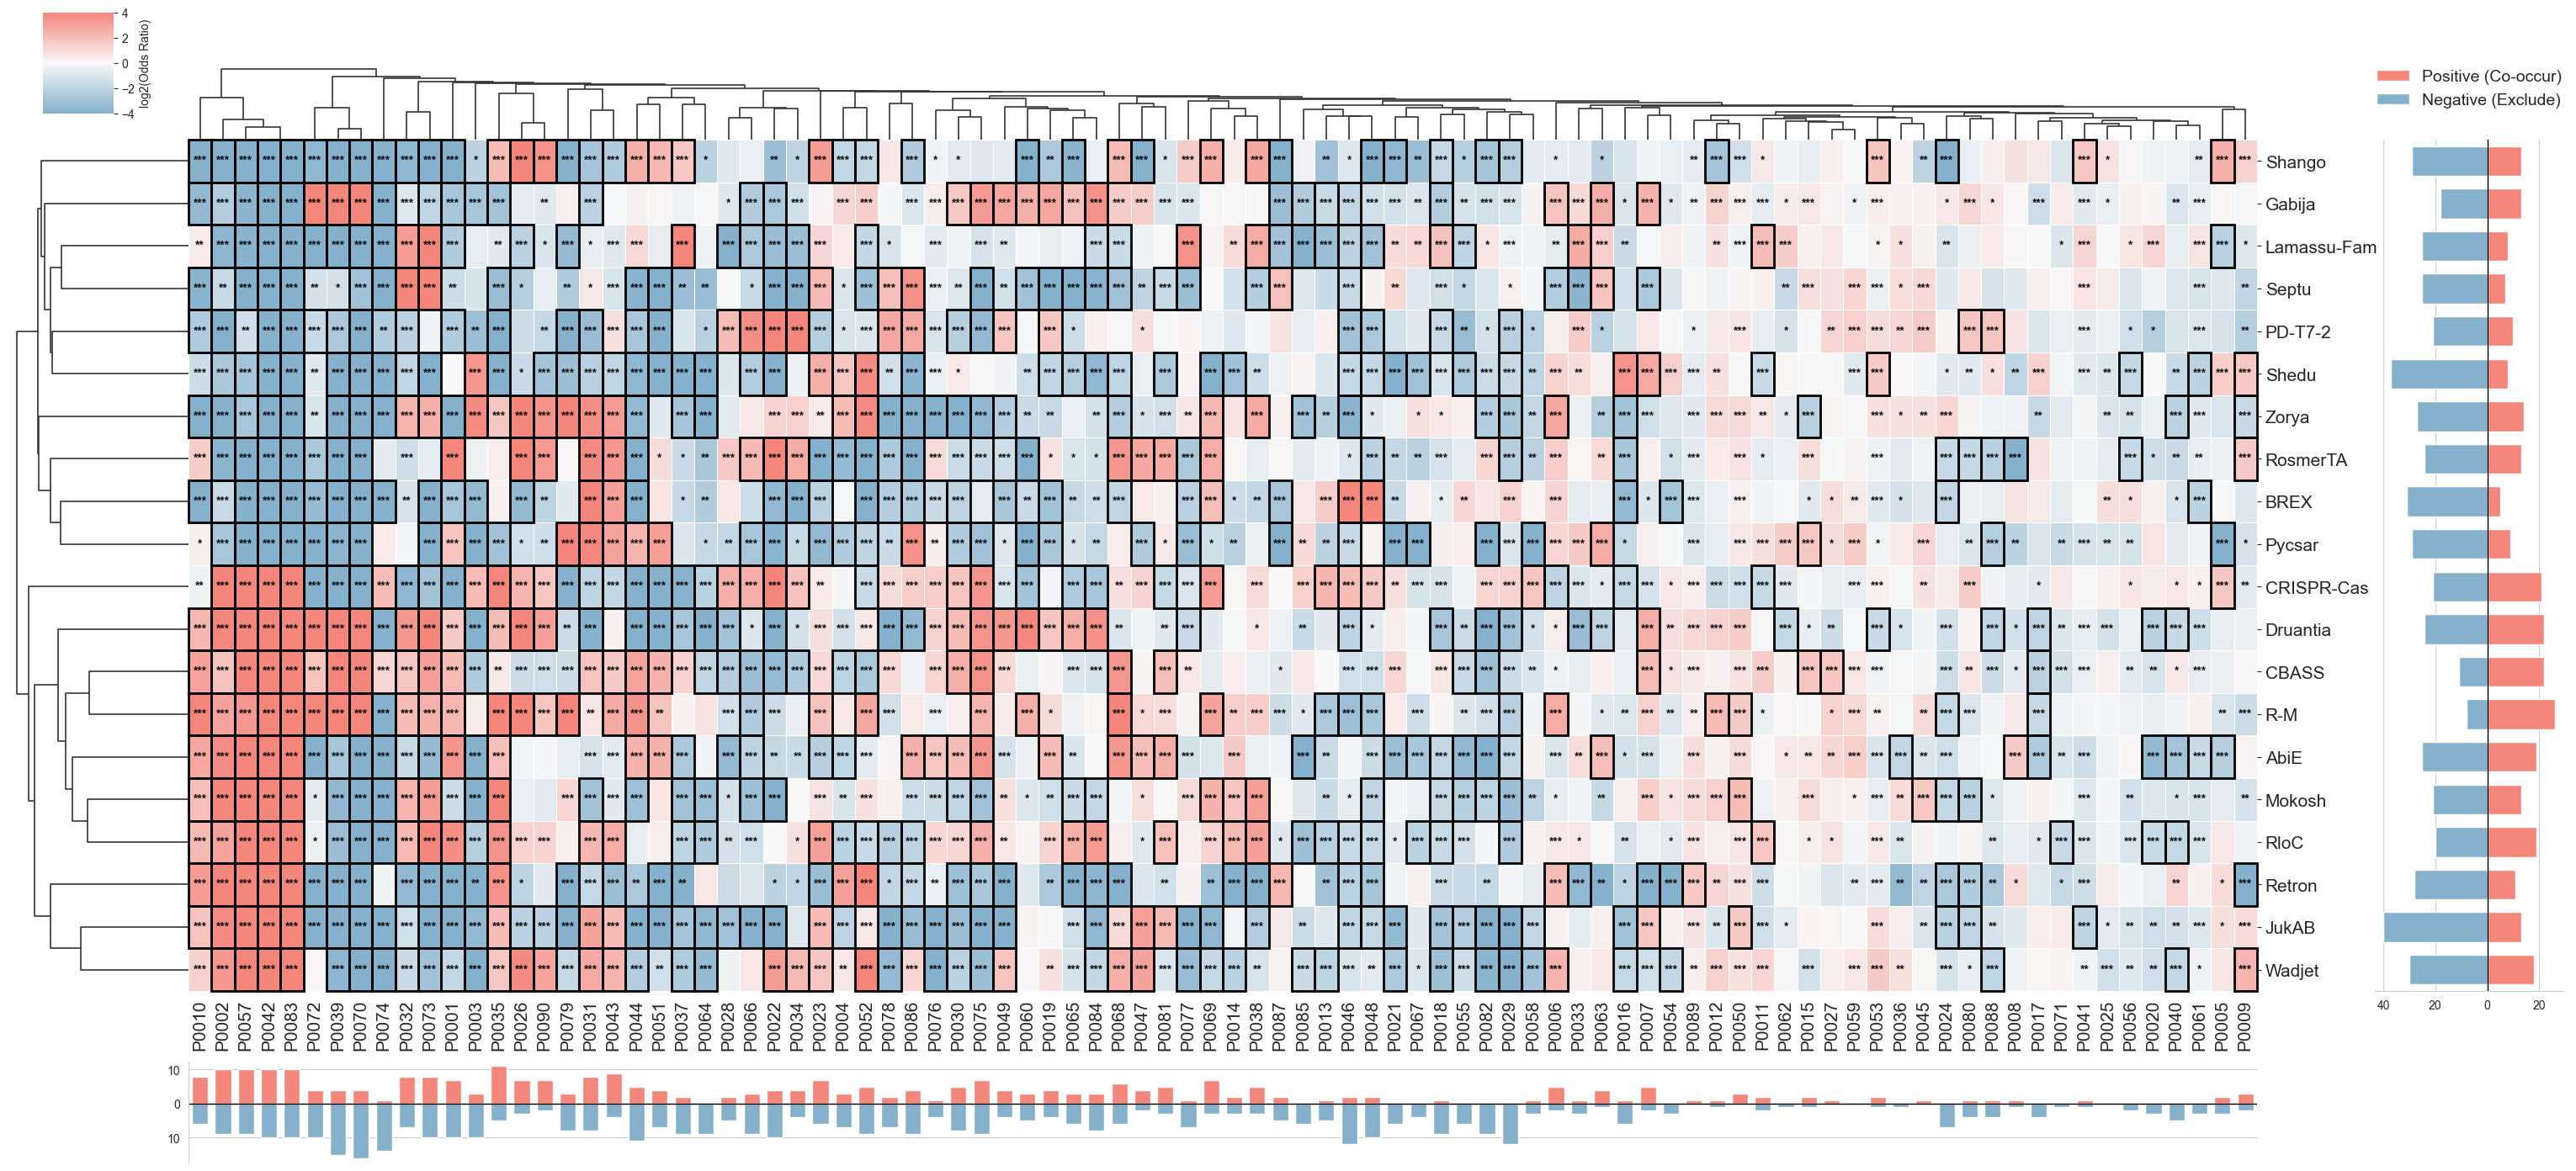

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.patches as patches
import matplotlib.ticker as ticker

# ================= 1. 自定义阈值参数 =================
OR_THRESHOLD = 3.0
P_VAL_THRESHOLD = 0.001
# =====================================================

# 2. 读取数据 (请确保路径正确)
data = pd.read_csv("").set_index("Prophage").astype(float)
p_numeric_data = pd.read_csv("").set_index("Prophage").astype(float)

# 3. 核心逻辑：连续数据转换
data_safe = data.replace(0, 0.01)
data_safe = data_safe.replace([np.inf, -np.inf], np.nan)
log2_data = np.log2(data_safe).fillna(0)
log2_data = log2_data.clip(lower=-4, upper=4)

# 4. 生成高亮掩码 (Mask) 及 正负相关统计掩码
log2_thresh = np.log2(OR_THRESHOLD)
highlight_mask = (np.abs(log2_data) >= log2_thresh) & (p_numeric_data < P_VAL_THRESHOLD)

pos_mask = (log2_data >= log2_thresh) & (p_numeric_data < P_VAL_THRESHOLD)
neg_mask = (log2_data <= -log2_thresh) & (p_numeric_data < P_VAL_THRESHOLD)

plot_data = log2_data.T
p_plot_data = p_numeric_data.T
mask_data = highlight_mask.T
pos_mask_data = pos_mask.T
neg_mask_data = neg_mask.T

# 行统计 (Defense Systems)
pos_counts = pos_mask_data.sum(axis=1)
neg_counts = neg_mask_data.sum(axis=1)

# 列统计 (Prophages) - 新增
pos_col_counts = pos_mask_data.sum(axis=0)
neg_col_counts = neg_mask_data.sum(axis=0)

# 5. 生成显著性星号标记
def pval_to_stars(p):
    if pd.isna(p): return ""
    if p < 0.001: return "***"
    elif p < 0.01: return "**"
    elif p < 0.05: return "*"
    else: return ""

annot_data = p_plot_data.applymap(pval_to_stars)

# 6. 绘制聚类热图 (Clustermap)
fig_kws = {'figsize': (28, 12)}
custom_cmap = LinearSegmentedColormap.from_list("custom_divergent", ["#86B1CD", "#F8F8F8", "#F4867C"])

g = sns.clustermap(
    plot_data,
    annot=annot_data,
    fmt="",
    cmap=custom_cmap,
    center=0,
    vmin=-4, vmax=4,
    linewidths=0.5,
    linecolor='white',
    dendrogram_ratio=(0.08, 0.08),

    cbar_pos=(0.02, 0.94, 0.03, 0.1),
    cbar_kws={"label": "log2(Odds Ratio)", "orientation": "vertical", "ticks": [-4, -2, 0, 2, 4]},

    annot_kws={"fontsize": 10, "color": "black", "weight": "bold"},
    tree_kws={"linewidths": 1.2},
    **fig_kws
)

g.ax_heatmap.set_yticklabels(g.ax_heatmap.get_ymajorticklabels(), rotation=0, fontsize=15)
g.ax_heatmap.set_xticklabels(g.ax_heatmap.get_xmajorticklabels(), rotation=90, fontsize=15)
# g.ax_heatmap.set_xlabel("Prophages")
# g.ax_heatmap.set_ylabel("Defense Systems")

g.ax_heatmap.set_xlabel("")

# ================= 7. 在热图上画方框 =================
row_order = g.dendrogram_row.reordered_ind
col_order = g.dendrogram_col.reordered_ind
ordered_mask = mask_data.iloc[row_order, col_order].values

for y in range(ordered_mask.shape[0]):
    for x in range(ordered_mask.shape[1]):
        if ordered_mask[y, x]:
            rect = patches.Rectangle(
                (x, y), 1, 1,
                fill=False, edgecolor='black', lw=2, clip_on=False
            )
            g.ax_heatmap.add_patch(rect)

# ================= 8. 在右侧拼接条形图 =================
ordered_pos_counts = pos_counts.iloc[row_order].values
ordered_neg_counts = neg_counts.iloc[row_order].values

hm_pos = g.ax_heatmap.get_position()

LABEL_GAP = 0.05
BAR_WIDTH = 0.08

bar_ax = g.fig.add_axes([hm_pos.x1 + LABEL_GAP, hm_pos.y0, BAR_WIDTH, hm_pos.height])
bar_ax.set_facecolor('none')

y_positions = np.arange(len(row_order)) + 0.5

bar_ax.barh(y_positions, ordered_pos_counts, color="#F4867C", height=0.7, label="Positive (Co-occur)")
bar_ax.barh(y_positions, -ordered_neg_counts, color="#86B1CD", height=0.7, label="Negative (Exclude)")

bar_ax.set_ylim(g.ax_heatmap.get_ylim())
bar_ax.axvline(0, color='black', linewidth=1)

bar_ax.set_yticks([])
bar_ax.spines['top'].set_visible(False)
bar_ax.spines['right'].set_visible(False)
bar_ax.spines['left'].set_visible(False)

bar_ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f"{int(abs(x))}"))
bar_ax.legend(loc="lower center", bbox_to_anchor=(0.5, 1.02), frameon=False, fontsize=14)


# ================= 9. 核心新增：在下方拼接条形图 =================
ordered_pos_col_counts = pos_col_counts.iloc[col_order].values
ordered_neg_col_counts = neg_col_counts.iloc[col_order].values

BOTTOM_GAP = 0.07
BOTTOM_HEIGHT = 0.1

bottom_ax = g.fig.add_axes([hm_pos.x0, hm_pos.y0 - BOTTOM_GAP - BOTTOM_HEIGHT, hm_pos.width, BOTTOM_HEIGHT])
bottom_ax.set_facecolor('none')

x_positions = np.arange(len(col_order)) + 0.5

# 绘制垂直发散条形图 (正相关向上，负相关向下)
bottom_ax.bar(x_positions, ordered_pos_col_counts, color="#F4867C", width=0.7)
bottom_ax.bar(x_positions, -ordered_neg_col_counts, color="#86B1CD", width=0.7)

# 强制与热图的 X 轴完全对齐
bottom_ax.set_xlim(g.ax_heatmap.get_xlim())
bottom_ax.axhline(0, color='black', linewidth=1)

bottom_ax.set_xticks([])
bottom_ax.spines['top'].set_visible(False)
bottom_ax.spines['right'].set_visible(False)
bottom_ax.spines['bottom'].set_visible(False) # 隐藏底边框，只留 0 基准线

bottom_ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda y, pos: f"{int(abs(y))}"))


# ================= 保存与展示 =================
# bbox_inches='tight' 会确保移到右侧和下方的条形图都不会被裁切掉
plt.show()

--- X轴标签聚类后的顺序 (共归纳出 90 列) ---
['P0002', 'P0010', 'P0068', 'P0063', 'P0051', 'P0035', 'P0036', 'P0041', 'P0050', 'P0062', 'P0052', 'P0057', 'P0006', 'P0039', 'P0029', 'P0042', 'P0028', 'P0075', 'P0013', 'P0024', 'P0058', 'P0018', 'P0031', 'P0069', 'P0085', 'P0088', 'P0030', 'P0055', 'P0077', 'P0078', 'P0080', 'P0086', 'P0066', 'P0023', 'P0054', 'P0003', 'P0072', 'P0033', 'P0044', 'P0008', 'P0004', 'P0053', 'P0089', 'P0009', 'P0025', 'P0090', 'P0020', 'P0027', 'P0056', 'P0005', 'P0064', 'P0049', 'P0082', 'P0017', 'P0040', 'P0061', 'P0076', 'P0048', 'P0074', 'P0022', 'P0065', 'P0038', 'P0045', 'P0012', 'P0014', 'P0015', 'P0087', 'P0081', 'P0016', 'P0011', 'P0007', 'P0046', 'P0079', 'P0026', 'P0019', 'P0032', 'P0059', 'P0084', 'P0001', 'P0043', 'P0021', 'P0034', 'P0073', 'P0037', 'P0060', 'P0071', 'P0070', 'P0083', 'P0047', 'P0067']
1: P0002
2: P0010
3: P0068
4: P0063
5: P0051
6: P0035
7: P0036
8: P0041
9: P0050
10: P0062
11: P0052
12: P0057
13: P0006
14: P0039
15: P0029
16: P0042
17: P00

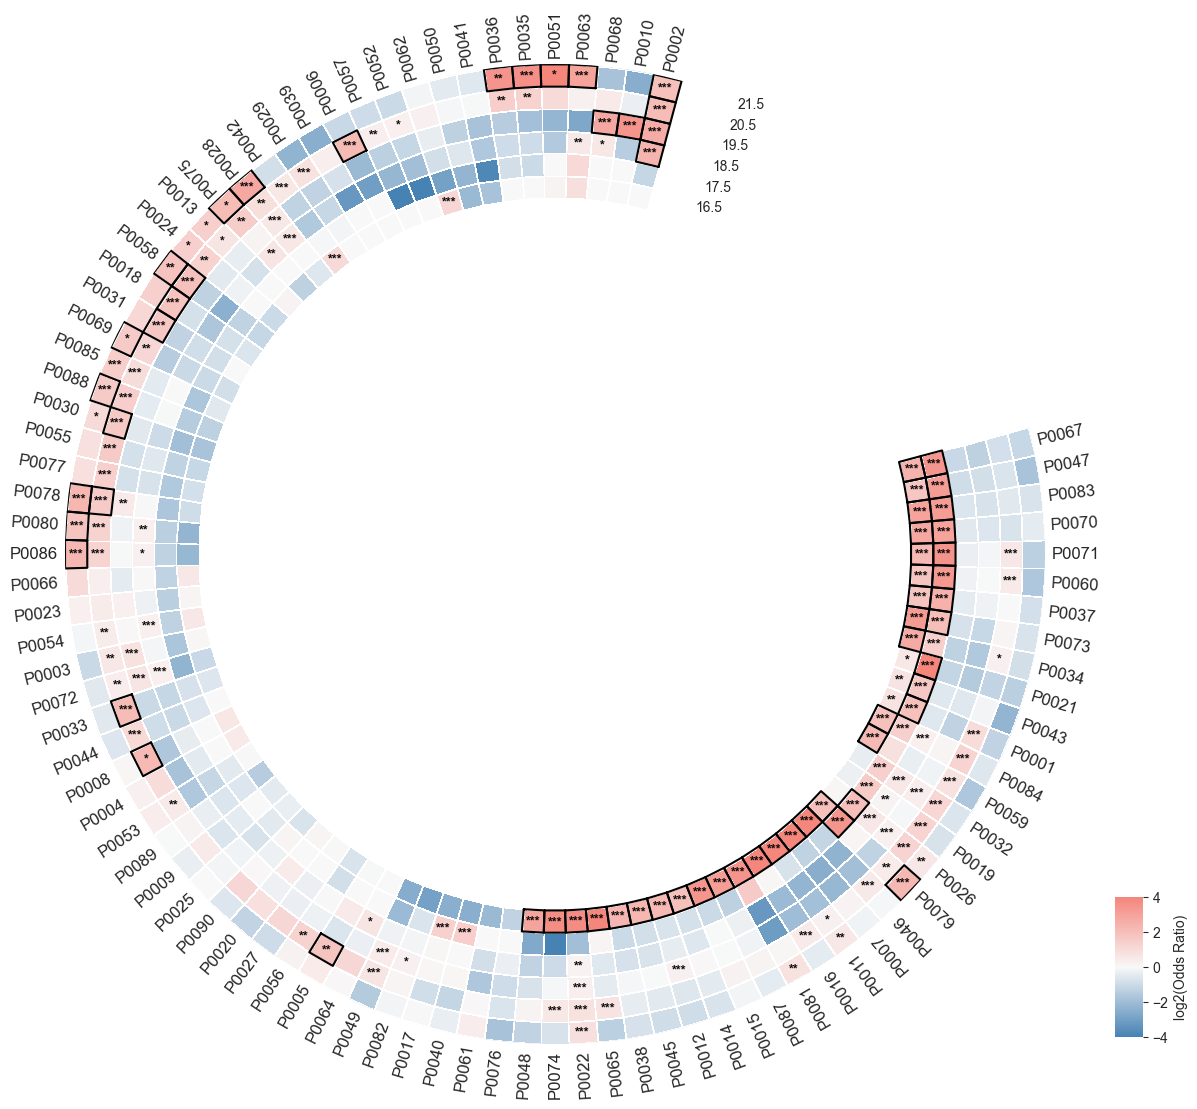

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy.spatial import distance
from scipy.cluster import hierarchy


data = pd.read_csv("").set_index("Cluster_ID").astype(float)
significance_data = pd.read_csv("").set_index("Cluster_ID").astype(str)

data_safe = data.replace(0, 0.01)
data_safe = data_safe.replace([np.inf, -np.inf], np.nan)
log2_data = np.log2(data_safe).fillna(0)
log2_data = log2_data.clip(lower=-4, upper=4)

def clean_significance(val):
    if pd.isna(val) or val == "nan" or val == "ns":
        return ""
    return str(val)

annot_data_cleaned = significance_data.map(clean_significance)

row_linkage = hierarchy.linkage(distance.pdist(log2_data), method='average')
row_order = hierarchy.leaves_list(row_linkage)

col_linkage = hierarchy.linkage(distance.pdist(log2_data.T), method='average')
col_order = hierarchy.leaves_list(col_linkage)

plot_data = log2_data.iloc[row_order, col_order]
annot_data = annot_data_cleaned.iloc[row_order, col_order]
plot_or_data = data.iloc[row_order, col_order]

# 获取聚类后的列名列表
ordered_x_labels = plot_data.columns.tolist()

print("--- X轴标签聚类后的顺序 (共归纳出 {} 列) ---".format(len(ordered_x_labels)))
print(ordered_x_labels)
for idx, label in enumerate(ordered_x_labels, 1):
    print(f"{idx}: {label}")

fig, ax = plt.subplots(figsize=(14, 14), subplot_kw={'projection': 'polar'})

custom_cmap = LinearSegmentedColormap.from_list("custom_divergent", ["#4682B4", "#F8F8F8", "#F4867C"])

num_rows, num_cols = plot_data.shape
inner_radius = 16
outer_radius = inner_radius + num_rows

gap_angle = np.deg2rad(60)

theta = np.linspace(gap_angle / 2, 2 * np.pi - gap_angle / 2, num_cols + 1)
r = np.linspace(inner_radius, outer_radius, num_rows + 1)
Theta, R = np.meshgrid(theta, r)

c = ax.pcolormesh(Theta, R, plot_data.values, cmap=custom_cmap, vmin=-4, vmax=4,
                  edgecolors='white', linewidth=0.5)

ax.set_theta_offset(np.pi / 4)


or_threshold = 3.0  # OR 阈值 (例如: >3 或 <1/3)
min_stars = 1       # P值阈值 (最少需要的星号数量，1代表至少有'*'即p<0.05)

# 初始化显著正相关与负相关的计数器
sig_positive_count = 0
sig_negative_count = 0

for i in range(num_rows):
    for j in range(num_cols):
        or_val = plot_or_data.iloc[i, j]
        sig_str = annot_data.iloc[i, j] # 获取该格子的显著性标记字符串

        # 判断条件：P 值星号数量是否达标 (p < 0.05)
        p_condition = sig_str.count('*') >= min_stars

        # 统计功能：OR > 1 为正相关，OR < 1 为负相关
        if p_condition and pd.notna(or_val):
            if or_val > 1.0:
                sig_positive_count += 1
            elif or_val < 1.0:
                sig_negative_count += 1

        # 高亮判断条件：OR 值是否达到设定的极端阈值 (例如 >3 或 <1/3)
        or_condition = pd.notna(or_val) and (or_val > or_threshold or or_val < 1.0 / or_threshold)

        # 只有两个条件同时满足 (and)，才绘制黑框
        if or_condition and p_condition:
            t_start, t_end = theta[j], theta[j+1]
            r_start, r_end = r[i], r[i+1]

            t_box = [t_start, t_end, t_end, t_start, t_start]
            r_box = [r_start, r_start, r_end, r_end, r_start]

            ax.plot(t_box, r_box, color='black', linewidth=1.5, zorder=3)

# 循环结束后，打印统计结果
print("--- 显著性统计 (P < 0.05) ---")
print(f"显著正相关 (OR > 1) 数量: {sig_positive_count}")
print(f"显著负相关 (OR < 1) 数量: {sig_negative_count}")
# ------------------------------------------


theta_centers = (theta[:-1] + theta[1:]) / 2
r_centers = (r[:-1] + r[1:]) / 2

for i in range(num_rows):
    for j in range(num_cols):
        text = annot_data.iloc[i, j]
        if text:
            ax.text(
                theta_centers[j], r_centers[i], text,
                ha='center', va='center', color='black',
                fontsize=9, weight='bold', zorder=4
            )


for j in range(num_cols):
    angle_rad = theta_centers[j]
    angle_deg = np.degrees(angle_rad)
    label = plot_data.columns[j]

    if 90 < angle_deg < 270:
        rotation = angle_deg + 225
        ha = 'right'
    else:
        rotation = angle_deg + 45
        ha = 'left'

    ax.text(angle_rad, outer_radius + 0.3, label,
            rotation=rotation, ha=ha, va='center', rotation_mode='anchor', fontsize=12)


ax.set_yticks(r_centers)
ax.grid(False)
ax.spines['polar'].set_visible(False)
ax.set_xticks([])


cbar_ax = fig.add_axes([0.85, 0.15, 0.02, 0.1])
cbar = plt.colorbar(c, cax=cbar_ax)
cbar.set_label("log2(Odds Ratio)", fontsize=10)
cbar.outline.set_visible(False)

plt.subplots_adjust(left=0.1, right=0.8)
#

plt.show()

D:\softerware_scientific_research\python_all_inone\Lib\site-packages\ptitprince\PtitPrince.py:1070: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


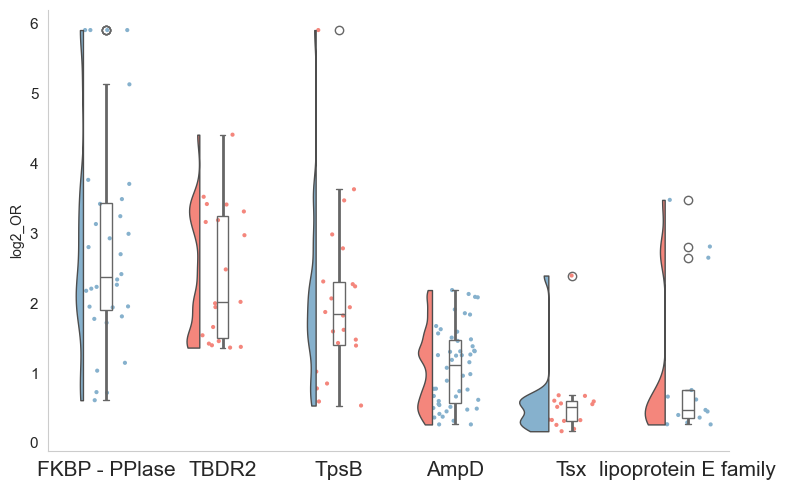

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ptitprince as pt


or_file = ""
p_file = ""

or_data = pd.read_csv(or_file, index_col="Cluster_ID").astype(float)
p_data = pd.read_csv(p_file, index_col="Cluster_ID").astype(str)

# log2(OR) 变换
data_safe = or_data.replace(0, 0.01)
data_safe = data_safe.replace([np.inf, -np.inf], np.nan)

log2_data = np.log2(data_safe).fillna(0)
log2_data = log2_data.clip(lower=-6, upper=6)


df_log2 = log2_data.reset_index().melt(
    id_vars="Cluster_ID",
    var_name="Prophage",
    value_name="log2_OR"
)

df_or = or_data.reset_index().melt(
    id_vars="Cluster_ID",
    var_name="Prophage",
    value_name="OR_original"
)

df_p = p_data.reset_index().melt(
    id_vars="Cluster_ID",
    var_name="Prophage",
    value_name="Significance"
)

df_merged = df_log2.merge(df_or, on=["Cluster_ID", "Prophage"]) \
                   .merge(df_p, on=["Cluster_ID", "Prophage"])


def is_significant(val):
    if pd.isna(val) or val == "nan" or val == "ns":
        return False
    return "*" in str(val)

mask_or = df_merged["OR_original"] > 1.0
mask_p = df_merged["Significance"].map(is_significant)

df_filtered = df_merged[mask_or & mask_p].copy()


order = df_filtered.groupby("Cluster_ID")["log2_OR"] \
                   .median() \
                   .sort_values(ascending=False) \
                   .index.tolist()

color_1 = "#86B1CD"
color_2 = "#F4867C"
palette_list = [color_1 if i % 2 == 0 else color_2 for i in range(len(order))]


fig, ax = plt.subplots(figsize=(8, 5))

# ✅ 正确设置背景（关键修复点）
# fig.patch.set_facecolor("white")
# ax.set_facecolor("white")

pt.RainCloud(
    data=df_filtered,
    y="log2_OR",
    x='Cluster_ID',
    palette=palette_list,
    order=order,
    orient="v",
    width_viol=0.5,
    width_box=0.1,
    jitter=0.2,
    alpha=1,
    pointplot=False,
    ax=ax,
    **{"point_size": 3}
)


# plt.axhline(0, color="black", linestyle="--", linewidth=1, alpha=0.5)

# plt.title(
#     "Raincloud Plot: Significant Positively Correlated Prophages (OR > 1, P < 0.05)",
#     fontsize=16,
#     weight="bold",
#     pad=20
# )

# plt.xlabel("Defense Systems", fontsize=14, weight="bold")
plt.xlabel(None)
# plt.ylabel(r"$\log_2(\mathrm{Odds\ Ratio})$", fontsize=16)

plt.xticks(rotation=0, ha="center", fontsize=15)
plt.yticks(fontsize=11)
plt.grid(False)
# sns.despine()
ax.spines["right"].set_visible(False)
ax.spines["top"].set_visible(False)
plt.tight_layout()

plt.show()